# LKIPA Planck Spectroscopy Analysis

Here we fit the planck data to the bosonic noise temperature curve to evaluate the added photons along the output line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

import importlib
import LKIPA_resonance_PSD as psd
importlib.reload(psd)

<module 'LKIPA_resonance_PSD' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/LKIPA_resonance_PSD.py'>

# 0. Functions

---


## 0.1 Load hdf5 data

In [ ]:
# Load Exp Data
def load_ExpData(file_):
    with h5py.File(file_, "r") as dataset:
        # Data is stored under "Planck Spectroscopy/{myrun}/..."
        sample_grp = dataset["Planck Spectroscopy"]
        myrun = list(sample_grp.keys())[0]
        run_grp = sample_grp[myrun]

        return {
            "run":          myrun,
            "freq_comb":    np.asarray(run_grp["freq comb"]),
            "USB":          np.asarray(run_grp["USB"]),
            "LSB":          np.asarray(run_grp["LSB"]),
            "temperature":  np.asarray(run_grp["temperature"]),
        }

In [ ]:
# file = '/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/LKIPA/2026-03-LKIPA-planck_568.52mk.hdf5'

# data = load_ExpData(file_=file)

# covariance_usb = np.array(data['USB'])
# covariance_lsb = np.array(data['LSB'])
# freq_comb      = data['freq_comb']

# modes = int(len(freq_comb))
# print('Modes = ' + str(modes))

## 0.2 Covariance matrix from USB, LSB data

In [ ]:
def covariance_matrix(lsb_arr, usb_arr, chunk_size=50_000):
    """
    Compute the quadrature covariance matrix over [LSB | USB] modes without
    materialising the full concatenated array.

    Uses the single-pass identity:
        cov = (ΣxxT - N * mean ⊗ mean) / (N - 1)

    Memory per chunk: chunk_size × 2*(M_lsb + M_usb) × 8 bytes
    e.g. chunk_size=50_000, 192 modes → ~153 MB
    """
    N      = lsb_arr.shape[0]
    M_lsb  = lsb_arr.shape[1]
    M_usb  = usb_arr.shape[1]
    M2     = 2 * (M_lsb + M_usb)   # total quadratures

    sum_x  = np.zeros(M2,       dtype=np.float64)
    sum_xx = np.zeros((M2, M2), dtype=np.float64)

    for i in tqdm(range(0, N, chunk_size), desc="Building covariance"):
        lsb_c  = lsb_arr[i:i + chunk_size]
        usb_c  = usb_arr[i:i + chunk_size]
        n      = len(lsb_c)

        xp = np.empty((n, M2), dtype=np.float64)
        # LSB quadratures: cols 0 .. 2*M_lsb-1, interleaved Re/Im
        xp[:, 0:2*M_lsb:2]   = np.real(lsb_c)
        xp[:, 1:2*M_lsb:2]   = np.imag(lsb_c)
        # USB quadratures: cols 2*M_lsb .. M2-1, interleaved Re/Im
        xp[:, 2*M_lsb::2]    = np.real(usb_c)
        xp[:, 2*M_lsb+1::2]  = np.imag(usb_c)

        sum_x  += xp.sum(axis=0)
        sum_xx += xp.T @ xp

    mean = sum_x / N
    return (sum_xx - N * np.outer(mean, mean)) / (N - 1)


# cov_mat = covariance_matrix(covariance_lsb, covariance_usb)


def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])

    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R

    return R_big @ cov_mat @ R_big.T

# theta   = 3*np.pi/16
# cov_mat = cov_rotation(cov_mat, theta)

## 0.3 Extract diagonal from single planck file and fit to lorentzian

In [ ]:
# ── Diagonal extraction ───────────────────────────────────────────────────────
def get_cov_diagonal(cov_mat, freq_comb, fNCO=4.429e9):
    """Return (freqs_GHz, power) for the full band, sorted ascending in frequency."""
    diag  = np.diag(cov_mat)
    M     = len(freq_comb)

    lsb_power = diag[0:2*M:2] + diag[1:2*M:2]
    usb_power = diag[2*M::2]  + diag[2*M+1::2]

    lsb_freqs = (2*fNCO - freq_comb) / 1e9
    usb_freqs = freq_comb / 1e9

    freqs = np.concatenate([lsb_freqs, usb_freqs])
    power = np.concatenate([lsb_power, usb_power])
    order = np.argsort(freqs)
    return freqs[order], power[order]


# ── Plot + optional Lorentzian fit ────────────────────────────────────────────
def plot_cov_diagonal(cov_mat, freq_comb, fNCO=4.429e9, f_L=None, f_R=None):
    """
    Plot the covariance-matrix diagonal as noise power vs frequency.
    If f_L and f_R (GHz) are provided, fit psd.lorentzian_fit_func within
    that bandwidth using psd.lorentz_fit and overlay the result.
    """
    freqs, power = get_cov_diagonal(cov_mat, freq_comb, fNCO)

    lsb_mask = freqs < fNCO / 1e9
    usb_mask = ~lsb_mask

    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
    ax.plot(freqs[lsb_mask], power[lsb_mask], color='blue',   lw=1, label='LSB')
    ax.plot(freqs[usb_mask], power[usb_mask], color='orange', lw=1, label='USB')

    if f_L is not None and f_R is not None:
        mask = (freqs >= f_L) & (freqs <= f_R)
        f_bw = freqs[mask]
        p_bw = power[mask]

        fit_params = psd.lorentz_fit(
            PSD_bandwidth=p_bw,
            f_arr_bandwidth=f_bw,
            lorentzian_fit_func=psd.lorentzian_fit_func,
        )
        fit_curve = psd.lorentzian_fit_func(f_bw, *fit_params)

        ax.plot(f_bw, fit_curve, color='red', lw=0.8, ls='--', label='Lorentzian fit')
        ax.axvspan(f_L, f_R, alpha=0.2, color='green',
#                    label=f'Fit BW [{f_L:.3f}, {f_R:.3f}] GHz'
                    )

        A_bg, B_bg, A_peak, f_0, gamma = fit_params
        info_text = (
            f"$T_{{MXC}}$ = {np.real(temp)} mK" "\n" 
            f"$A_{{peak}}$ = {A_peak:.4e}\n"
            f"$f_0$ = {f_0:.4f} GHz\n"
            f"$\\gamma$ = {np.abs(gamma)*1e3:.4f} MHz"
        )
        fig.subplots_adjust(right=0.78)
        fig.text(
            0.80, 0.5,
            info_text,
            ha='left', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.85)
        )

    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Noise power (a.u.)")
    ax.set_title("Covariance Matrix Diagonal vs Frequency")
    ax.legend()
    ax.grid()

    # plot_cov_diagonal(cov_mat, freq_comb, f_L=4.42, f_R=4.44)

# 1. Data Extraction
---
Loop over all HDF5 files, compute the covariance matrix, fit the diagonal, save figures, and collect fitting parameters.

In [ ]:
from scipy.integrate import quad
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import display, clear_output

data_folder     = '/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/LKIPA/'
figures_folder  = '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/Figures/LKIPA Planck'
fitting_folder  = '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/LKIPA Resonance Fitting Lockin 2026-04'
fNCO            = 4.429e9   # Hz

# Lorentzian fit bandwidth (GHz)
f_L, f_R = 4.42, 4.44

# Covariance rotation angle (same as testing section)
theta = 0

os.makedirs(figures_folder, exist_ok=True)
os.makedirs(fitting_folder, exist_ok=True)

# Sort by modification time: oldest file first (ascending temperature order)
files = sorted(glob.glob(os.path.join(data_folder, '*.hdf5')), key=os.path.getmtime)

# CSV path — written incrementally so results survive partial runs
csv_path = os.path.join(fitting_folder, 'LKIPA_planck_fit_params.csv')
csv_header = 'Temperature_mK,A_bg,B_bg,A_peak,f_0_GHz,gamma_GHz,lorentz_integral,bg_integral'
with open(csv_path, 'w') as f:
    f.write(csv_header + '\n')

# ── Running integrals plot (created once; re-displayed each iteration) ───────
fig_live, (ax_lor, ax_bg) = plt.subplots(figsize=(6, 8), nrows=2, dpi=150)

ax_lor.set_xlabel("Temperature (mK)")
ax_lor.set_ylabel("Lorentzian Integral (a.u. · GHz)")
ax_lor.set_title("Lorentzian PSD Integral over 20 MHz BW vs Temperature")
ax_lor.grid()
line_lor, = ax_lor.plot([], [], color='teal', lw=0.8, ls='--', marker='o')

ax_bg.set_xlabel("Temperature (mK)")
ax_bg.set_ylabel("Background Integral (a.u. · GHz)")
ax_bg.set_title("Linear Background Integral over 20 MHz BW vs Temperature")
ax_bg.grid()
line_bg, = ax_bg.plot([], [], color='crimson', lw=0.8, ls='--', marker='o')

fig_live.tight_layout()

# ── Main loop ─────────────────────────────────────────────────────────────────
results          = []
temps_so_far     = []
lor_ints_so_far  = []
bg_ints_so_far   = []

for idx, file in enumerate(tqdm(files, desc="Processing files")):
    try:
        data = load_ExpData(file_=file)
    except Exception as e:
        tqdm.write(f"Skipping {os.path.basename(file)}: load error — {e}")
        continue

    temp = float(np.real(data['temperature']))

    # --- Covariance matrix ---
    cov = covariance_matrix(data['LSB'], data['USB'])
    cov = cov_rotation(cov, theta)

    # --- Save covariance matrix figure (off-screen, no widget popup) ---
    fig_cov = Figure(figsize=(6, 6), dpi=150)
    FigureCanvasAgg(fig_cov)
    ax_cov = fig_cov.add_subplot(111)
    im = ax_cov.imshow(cov, aspect='equal', cmap='viridis', origin='upper')
    fig_cov.colorbar(im, ax=ax_cov)
    ax_cov.set_xlabel("Quadrature")
    ax_cov.set_ylabel("Quadrature")
    ax_cov.set_title(f"Covariance Matrix — T = {temp:.1f} mK")
    fig_cov.tight_layout()
    fig_cov.savefig(os.path.join(figures_folder, f'cov_mat_{temp:.1f}mK.png'), dpi=150)

    # --- Diagonal fit ---
    freqs, power = get_cov_diagonal(cov, data['freq_comb'], fNCO=fNCO)
    mask  = (freqs >= f_L) & (freqs <= f_R)
    f_bw  = freqs[mask]
    p_bw  = power[mask]

    if f_bw.size < 6:
        tqdm.write(f"Skipping {os.path.basename(file)}: only {f_bw.size} points in [{f_L}, {f_R}] GHz — freq range: [{freqs.min():.4f}, {freqs.max():.4f}]")
        continue

    try:
        fit_params = psd.lorentz_fit(
            PSD_bandwidth=p_bw,
            f_arr_bandwidth=f_bw,
            lorentzian_fit_func=psd.lorentzian_fit_func,
        )
    except Exception as e:
        tqdm.write(f"Skipping {os.path.basename(file)}: fit failed — {e}")
        continue

    A_bg, B_bg, A_peak, f_0, gamma = fit_params
    fit_curve = psd.lorentzian_fit_func(f_bw, *fit_params)

    # --- PSD integrals (same method as LKIPA-Resonance-Analysis) ---
    lor_integral = quad(
        lambda f: A_peak / (((f - f_0) / gamma) ** 2 + 1),
        f_L, f_R
    )[0]
    bg_integral = quad(
        lambda f: A_bg * f + B_bg,
        f_L, f_R
    )[0]

    # --- Save diagonal + fit figure (off-screen, no widget popup) ---
    lsb_mask = freqs < fNCO / 1e9
    fig_diag = Figure(figsize=(9, 4), dpi=150)
    FigureCanvasAgg(fig_diag)
    fig_diag.subplots_adjust(right=0.78)
    ax_diag = fig_diag.add_subplot(111)
    ax_diag.plot(freqs[lsb_mask],  power[lsb_mask],  color='blue',   lw=0.8, label='LSB')
    ax_diag.plot(freqs[~lsb_mask], power[~lsb_mask], color='orange', lw=0.8, label='USB')
    ax_diag.plot(f_bw, fit_curve, color='red', lw=1.5, ls='--', label='Lorentzian fit')
    ax_diag.axvspan(f_L, f_R, alpha=0.08, color='red')
    ax_diag.set_xlabel("Frequency (GHz)")
    ax_diag.set_ylabel("Noise power (a.u.)")
    ax_diag.set_title(f"Cov. Diagonal — T = {temp:.1f} mK")
    ax_diag.legend()
    ax_diag.grid()
    info_text = (
        f"$A_{{peak}}$ = {A_peak:.4e}\n"
        f"$f_0$ = {f_0:.6f} GHz\n"
        f"$\\gamma$ = {np.abs(gamma)*1e3:.4f} MHz"
    )
    fig_diag.text(
        0.80, 0.5, info_text,
        ha='left', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.85)
    )
    fig_diag.savefig(os.path.join(figures_folder, f'diag_fit_{temp:.1f}mK.png'), dpi=150)

    # --- Store results and write CSV row immediately ---
    row = [temp, A_bg, B_bg, A_peak, f_0, np.abs(gamma), lor_integral, bg_integral]
    results.append(row)
    with open(csv_path, 'a') as f:
        f.write(','.join(f'{v:.10g}' for v in row) + '\n')

    # --- Update running plot (clear_output + display, same pattern as power_ramp.py) ---
    temps_so_far.append(temp)
    lor_ints_so_far.append(lor_integral)
    bg_ints_so_far.append(bg_integral)
    sort_idx = np.argsort(temps_so_far)

    line_lor.set_xdata(np.array(temps_so_far)[sort_idx])
    line_lor.set_ydata(np.array(lor_ints_so_far)[sort_idx])
    ax_lor.relim()
    ax_lor.autoscale_view()

    line_bg.set_xdata(np.array(temps_so_far)[sort_idx])
    line_bg.set_ydata(np.array(bg_ints_so_far)[sort_idx])
    ax_bg.relim()
    ax_bg.autoscale_view()

    clear_output(wait=True)
    print(f"File {idx+1}/{len(files)} — T = {temp:.1f} mK  |  A_peak = {A_peak:.4e}  |  f_0 = {f_0:.6f} GHz  |  γ = {np.abs(gamma)*1e3:.4f} MHz")
    display(fig_live)

print(f"\nDone. Processed {len(results)}/{len(files)} files.")
print(f"Saved fitting parameters to {csv_path}")

# 2. Analysis
---

In [2]:
kipa_params = np.loadtxt(
    fname='/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/LKIPA Resonance Fitting Lockin 2026-04/LKIPA_planck_fit_params.csv',
    delimiter=',',
    skiprows=1
)

temp_list = kipa_params[:-1, 0]
A_bg_list = kipa_params[:-1, 1]
B_bg_list = kipa_params[:-1, 2]
A_peak_list = kipa_params[:-1, 3]
f_0_list = kipa_params[:-1, 4]
gamma_list = kipa_params[:-1, 5]
lor_int_list = kipa_params[:-1, 6]
bg_int_list = kipa_params[:-1, 7]

## 2.1 Lorentzian parameters

### *Background*

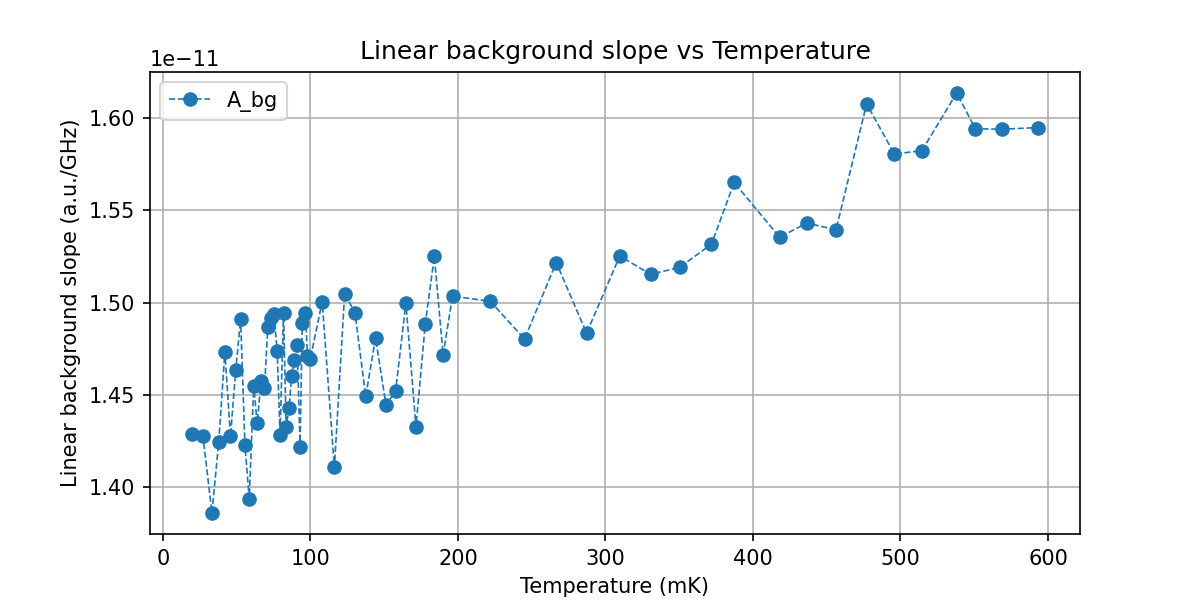

In [3]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list, A_bg_list, label='A_bg', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Linear background slope (a.u./GHz)")
ax.set_title("Linear background slope vs Temperature")
ax.legend()

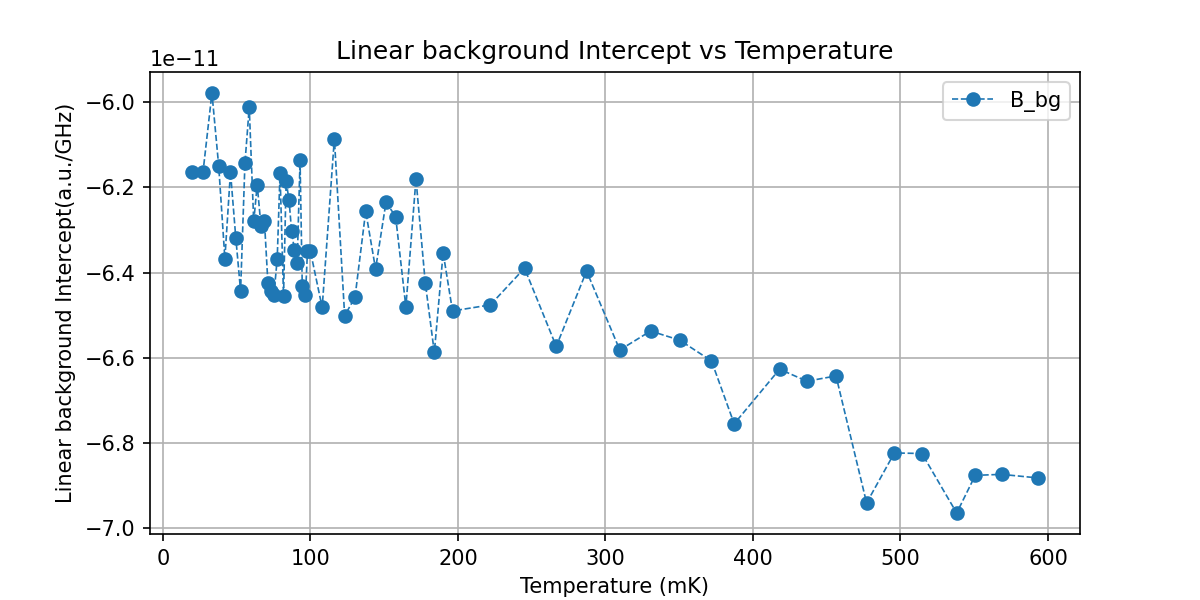

In [4]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list, B_bg_list, label='B_bg', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Linear background Intercept(a.u./GHz)")
ax.set_title("Linear background Intercept vs Temperature")
ax.legend()

### *Lorentzian*

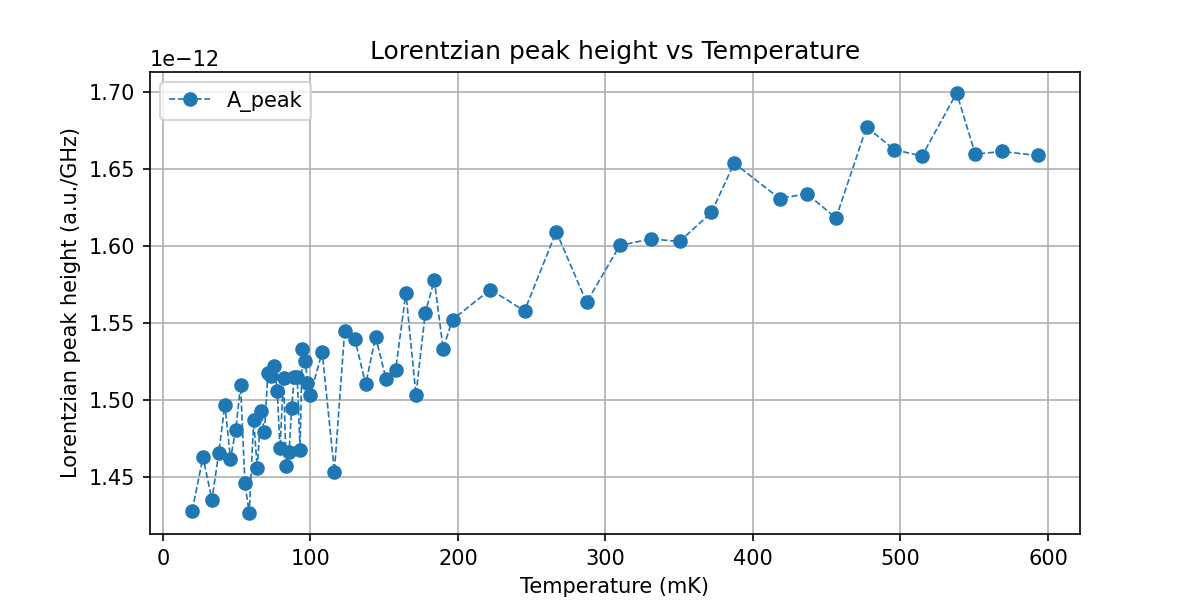

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list, A_peak_list, label='A_peak', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Lorentzian peak height (a.u./GHz)")
ax.set_title("Lorentzian peak height vs Temperature")
ax.legend()

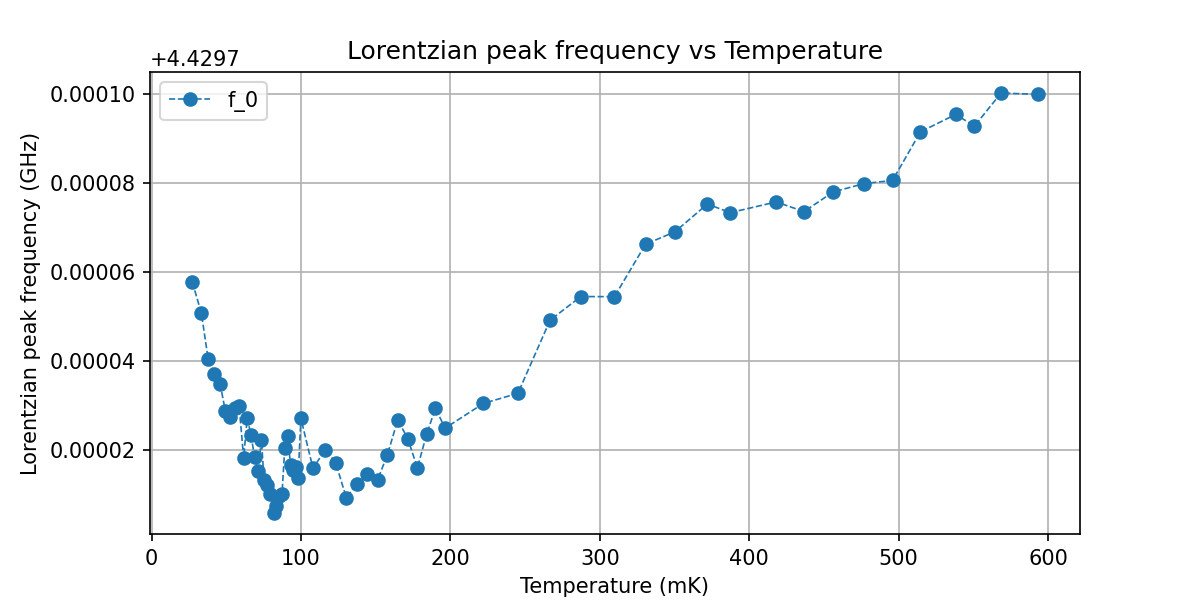

In [6]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list[1:], f_0_list[1:], label='f_0', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Lorentzian peak frequency (GHz)")
ax.set_title("Lorentzian peak frequency vs Temperature")
ax.legend()

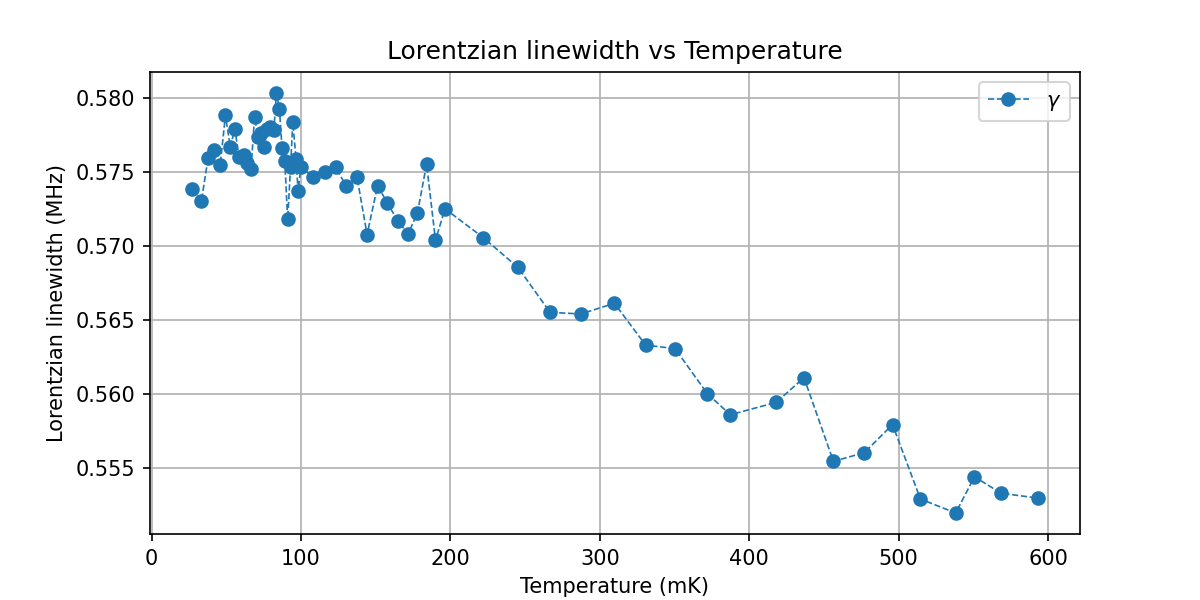

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list[1:], gamma_list[1:] * 1e3, label='$\\gamma$', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Lorentzian linewidth (MHz)")
ax.set_title("Lorentzian linewidth vs Temperature")
ax.legend()

### *Integrals*

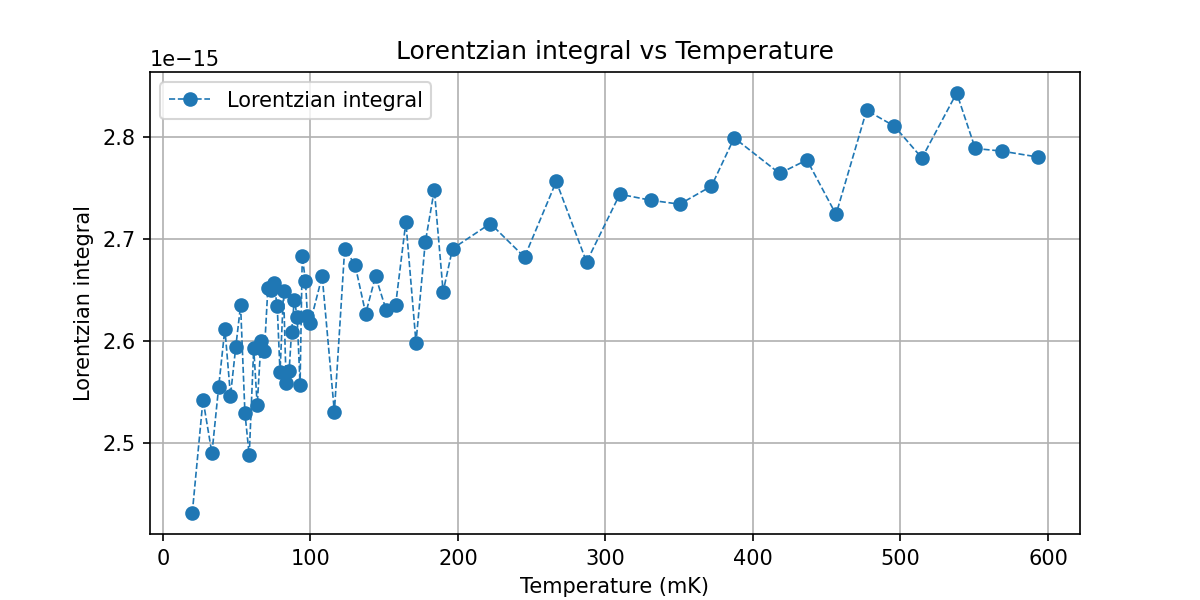

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list, lor_int_list, label='Lorentzian integral', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Lorentzian integral")
ax.set_title("Lorentzian integral vs Temperature")
ax.legend()

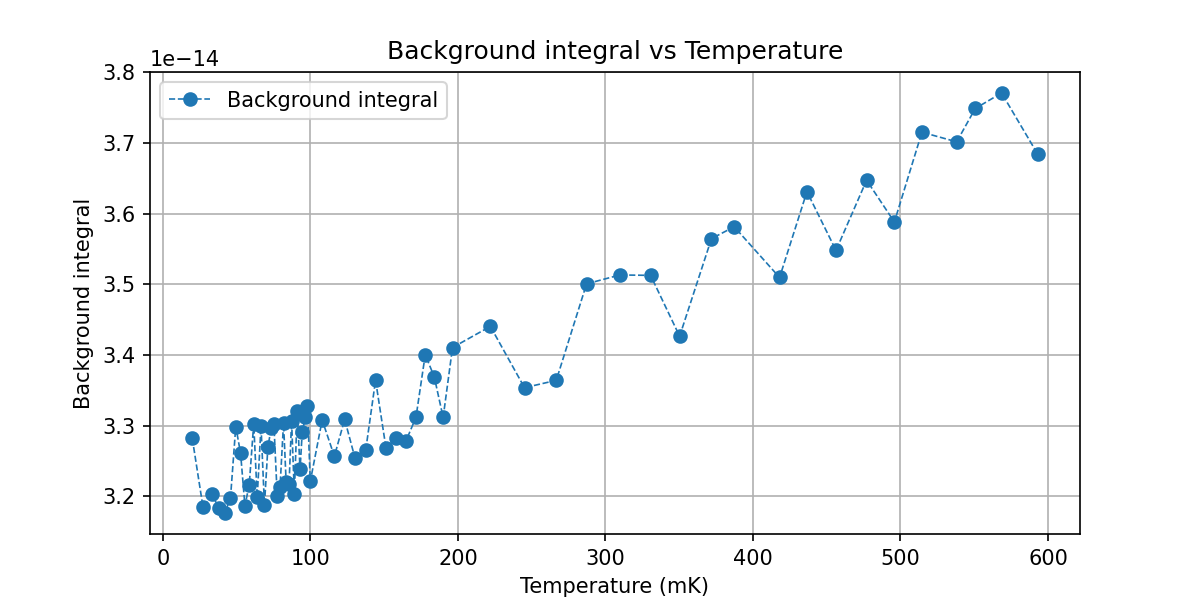

In [9]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(temp_list, bg_int_list, label='Background integral', marker='o', ls = '--', lw = 0.8)
ax.grid()
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("Background integral")
ax.set_title("Background integral vs Temperature")
ax.legend()